# Vergleich: LinearRegression() und LogisticRegression()
## Warum Linear Regression auch bei 0/1 Labels funktioniert

Wenn die Zielvariable 
y
y nur 0 oder 1 ist, kann man sie trotzdem wie eine kontinuierliche Zahl behandeln. Die lineare Regression versucht dann, den Mittelwert der Zielwerte für die gegebenen Features vorherzusagen.

Wenn dein Datensatz klar trennbare Klassen hat, liegen die vorhergesagten Werte der linearen Regression meist nahe bei 0 oder 1.

Dann reicht es, einen Schwellenwert (z. B. 0.5) zu nehmen, um die Klassenzugehörigkeit zu bestimmen.

Das erklärt, warum bei deinem Beispiel die Accuracy der linearen Regression fast so gut ist wie bei der logistischen Regression (94 % vs. 93 %).

Aber Achtung:

Linear Regression kann Werte <0 oder >1 vorhersagen → nicht wirklich Wahrscheinlichkeiten.

Logistic Regression ist robuster, besonders wenn Klassen nicht gut linear trennbar sind.

## Struktur der Aufrufe
- lin_model = LinearRegression()
- lin_model.fit(X_train, y_train)
- y_pred_lin = lin_model.predict(X_test)

- log_model = LogisticRegression()
- log_model.fit(X_train, y_train)
- y_pred_log = log_model.predict(X_test)

## Aufrufstruktur: fast identisch!

fit(X_train, y_train) trainiert die Modelle.

predict(X_test) gibt Vorhersagen.

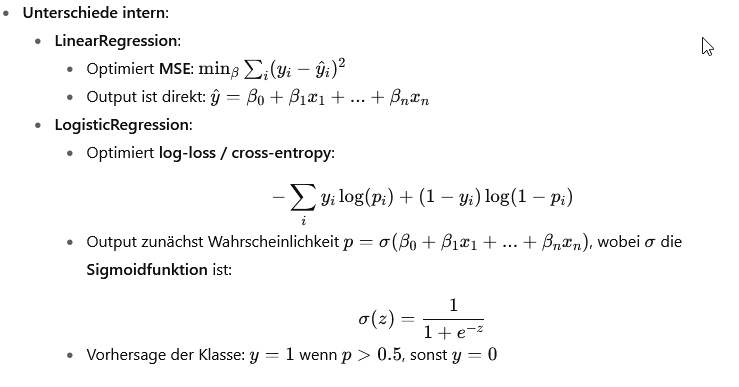

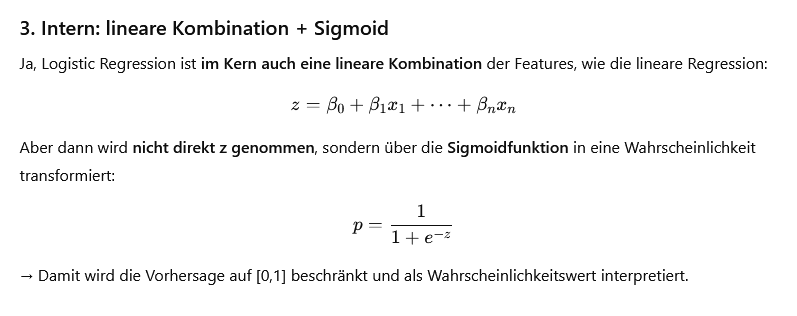


## Bespiel:
### Liste von Modellen
models = [

   **KNeighborsClassifier(n_neighbors=3),**
   
    RadiusNeighborsClassifier(radius=1.0),
   
    LogisticRegression(max_iter=200),
   
    DecisionTreeClassifier()
]

### Modelle definieren
models = [
    ("k-NN (k=5)", **KNeighborsClassifier(n_neighbors=5))**,
   
    ("Logistic Regression", LogisticRegression(max_iter=200, multi_class="multinomial")),
   
    ("Decision Tree", DecisionTreeClassifier(max_depth=4, random_state=42))
]
### Bei Logistic Regression passiert intern tatsächlich etwas, das sehr stark an das Training von neuronalen Netzen erinnert – nur viel einfacher. Lass mich das Schritt für Schritt erklären:

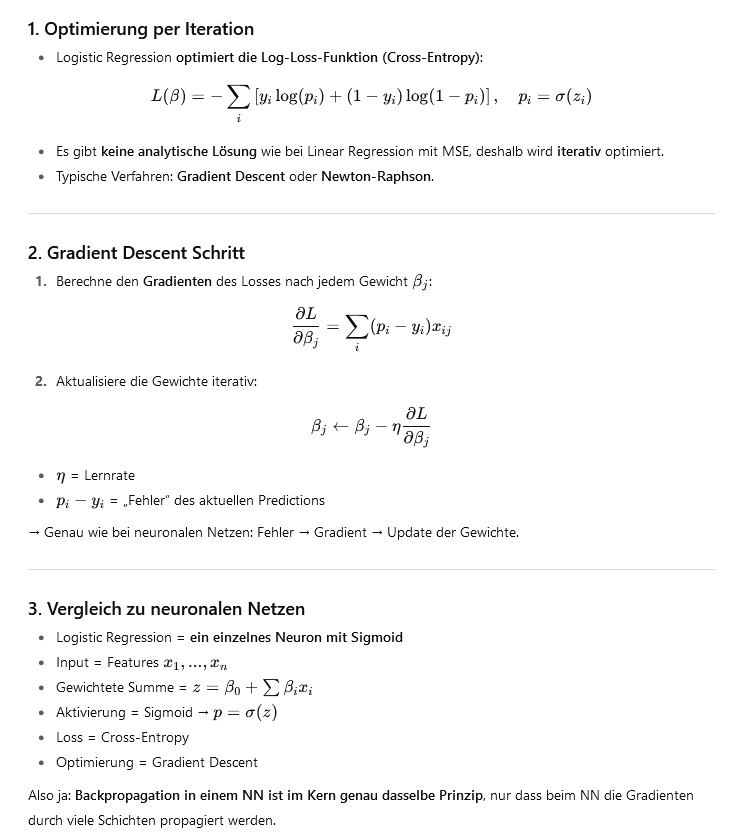


Linear Regression MSE: 0.0753119195436769
Linear Regression Accuracy (Threshold 0.5): 0.94
Logistic Regression Accuracy: 0.93
<class 'numpy.ndarray'> (1000, 5) (1000,)
[-0.52933211 -0.09338686 -1.52657236  0.4068465  -0.61969946]
[-0.97849955 -1.69067163  1.22930785 -0.70307052  0.20205497]
[-2.1715714   0.54578671  1.25343301  1.52772557  1.78078504]
[-0.15129922 -0.36550594  1.33571369  0.03835504 -0.00531744]
[-0.77737148  1.14603014 -2.47934266  0.29701431  1.51852217]
[ 0.17847666 -2.17706505  0.91500764  0.61809156 -0.42390939]
[-0.96265101  0.82278278  0.86240676 -0.17486305 -0.20833214]
[-0.06418416 -0.36131056 -1.51425877  0.50486088 -0.65310131]
[ 1.27946493 -0.86388296 -1.84897013  0.16467469 -0.56667776]
[-0.3692072   0.8419837  -0.51812914  0.16587132 -0.88095639]
         X1        X2        X3        X4        X5  y
0 -0.529332 -0.093387 -1.526572  0.406847 -0.619699  0
1 -0.978500 -1.690672  1.229308 -0.703071  0.202055  1
2 -2.171571  0.545787  1.253433  1.527726  1.78

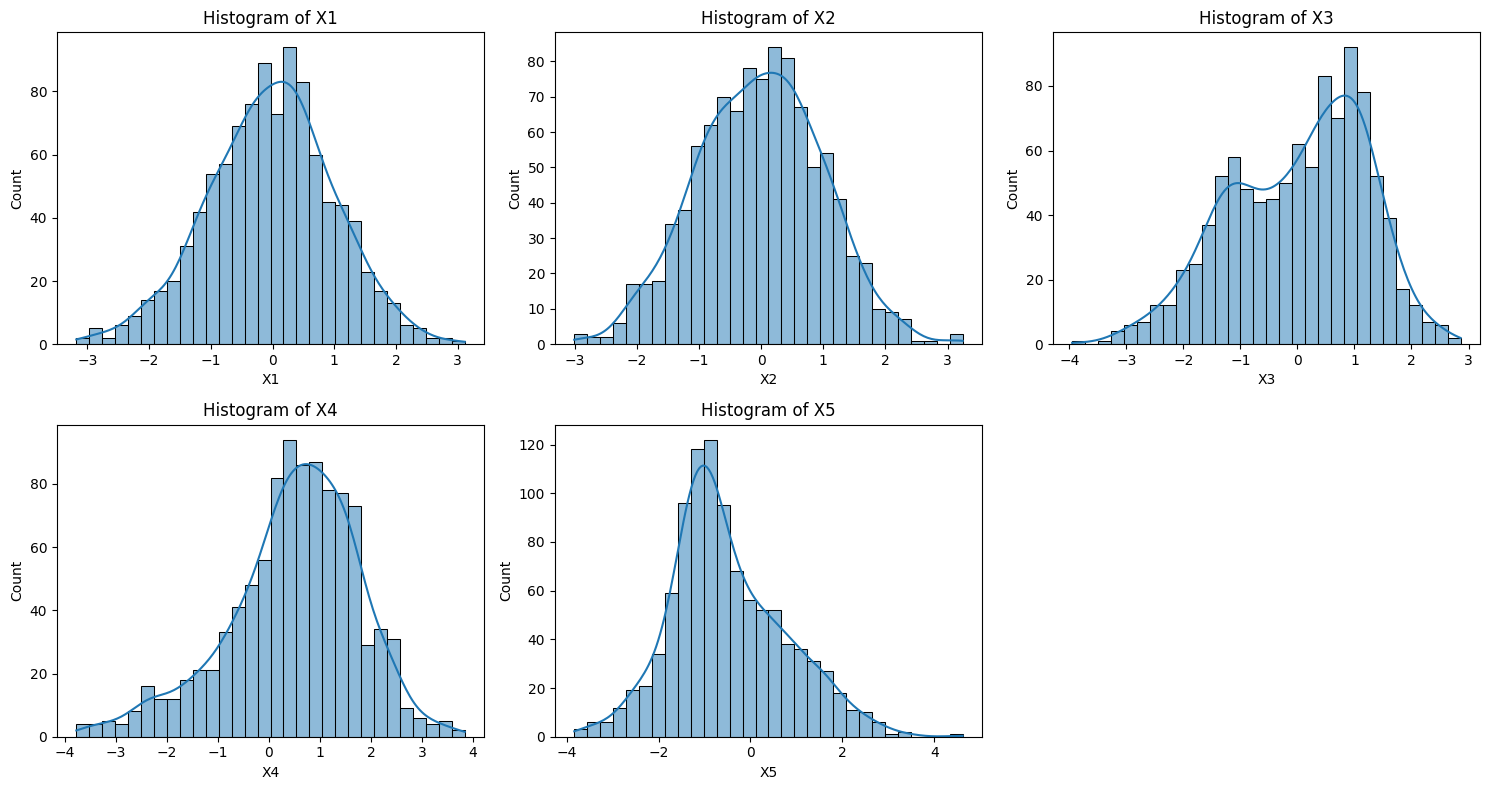

In [3]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score

# 1000 Samples, 5 Features, 2 Klassen
X, y = make_classification(n_samples=1000, n_features=5, n_informative=3, n_redundant=0, 
                           n_classes=2, random_state=42)

# Split in Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Lineare Regression ---
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)

# Lineare Regression gibt "Kontinuierliche Werte" → wir können Schwellenwert 0.5 nehmen
y_pred_lin_class = (y_pred_lin > 0.5).astype(int)

print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_lin))
print("Linear Regression Accuracy (Threshold 0.5):", accuracy_score(y_test, y_pred_lin_class))

# --- Logistische Regression ---
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))



print("==================================================")
# --------------------------------
# In DataFrame für Übersicht: Darstellung von Histogram
print(type(X), X.shape, y.shape)
for x in range(0, 10):
  print(X[x])
df = pd.DataFrame(X, columns=[f"X{i}" for i in range(1,6)])
df["y"] = y
print(df.head())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(df.columns[:5]):  # nur Features
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Histogram of {col}')

# Letztes leeres Subplot ausblenden
axes[-1].axis('off')

plt.tight_layout()
plt.show()


# wie man die 1000 z-Werte und Wahrscheinlichkeiten aus der logistischen Regression direkt berechnet. Wir nutzen die gelernten Gewichte (coef_) und den Bias (intercept_) aus LogisticRegression.

In [4]:
# Gewichte und Bias
beta = log_model.coef_[0]       # array([β1, β2, β3, β4, β5])
beta0 = log_model.intercept_[0] # β0

# Lineare Kombination z = β0 + β1*x1 + ... + βn*xn für alle Testdaten
z = np.dot(X_test, beta) + beta0
print("X_test: z.shape:",z.shape)
print("z-Werte (erste 10):",z[:10])

# Sigmoidfunktion für Wahrscheinlichkeiten
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

p = sigmoid(z)
print("Wahrscheinlichkeiten p(y=1) (erste 10):", p[:10])

# Klassenvorhersage nach Schwelle 0.5
y_pred_class = (p > 0.5).astype(int)
print("Vorhergesagte Klassen (erste 10):", y_pred_class[:10])

X_test: z.shape: (200,)
z-Werte (erste 10): [-0.19327545 -0.34153686 -5.87771872 -3.4619145   1.98479856 -0.05221251
  5.1606321   6.18834754  0.50807644 -1.41956438]
Wahrscheinlichkeiten p(y=1) (erste 10): [0.45183099 0.4154362  0.00279334 0.03041552 0.87919176 0.48694984
 0.99429467 0.99795099 0.62435544 0.19472988]
Vorhergesagte Klassen (erste 10): [0 0 0 0 1 0 1 1 1 0]
